In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path
from sklearn.decomposition import PCA
from IPython.display import display
CSV_PATH = Path(r"D:\research\code\all_roi_spectra200x200.csv")
OUT_DIR = Path(r"D:\research\code\diagonal_spike_tolerant_output")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR = Path(OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)


WL_MIN = 2100
WL_MAX = 2400

# PCAで通常スペクトルを何成分で再構成するか
# 3くらいが「通常変動は残しつつ、局所異常は残差に出す」用途でよさそう
N_PC_RECON = 3

# 見たい波長
TARGET_WLS = [2125.03, 2387.32]

# 各波長で想定する異常対角線
# d = y - x
TARGET_DIAG_RANGES = {
    2125.03: (166, 170),
    2387.32: (50, 54),
}

Z_THRESHOLD = 4.0


def nearest_band_index(target_wl, wavelengths):
    wavelengths = np.asarray(wavelengths, dtype=float)
    return int(np.argmin(np.abs(wavelengths - target_wl)))


def robust_zscore_1d(v):
    v = np.asarray(v, dtype=float)
    med = np.nanmedian(v)
    mad = np.nanmedian(np.abs(v - med))
    scale = mad / 0.6745

    if not np.isfinite(scale) or scale < 1e-12:
        scale = np.nanstd(v)

    if scale < 1e-12:
        return np.zeros_like(v)

    return (v - med) / scale


# ------------------------------------------------------------
# wave columns と wavelengths の準備
# ------------------------------------------------------------

wave_cols = [c for c in df.columns if c.startswith("wave_")]

wavelengths = np.array([
    float(re.search(r"wave_([0-9.]+)nm", c).group(1))
    for c in wave_cols
])

height = int(df["y"].max()) + 1
width = int(df["x"].max()) + 1

Y, X = np.indices((height, width))
D = Y - X

# 2100-2400 nmだけ使う
wl_mask = (wavelengths >= WL_MIN) & (wavelengths <= WL_MAX)
wl_pca = wavelengths[wl_mask]
cols_pca = np.array(wave_cols)[wl_mask]

X_raw = df[cols_pca].to_numpy(dtype=float)

# 波長ごとに標準化
mu = np.nanmean(X_raw, axis=0)
sd = np.nanstd(X_raw, axis=0, ddof=1)
sd[sd < 1e-12] = 1.0

X_std = (X_raw - mu) / sd

print("PCA input shape:", X_std.shape)
print("Wavelength range:", wl_pca[0], "to", wl_pca[-1], "nm")

PCA input shape: (40000, 25)
Wavelength range: 2100.05 to 2399.82 nm


In [4]:
def parse_wavelengths(columns):
    wave_cols = []
    wavelengths = []
    for c in columns:
        m = re.fullmatch(r'wave_([0-9]+(?:\.[0-9]+)?)nm', str(c))
        if m is not None:
            wave_cols.append(c)
            wavelengths.append(float(m.group(1)))
    return wave_cols, np.asarray(wavelengths, dtype=float)

def robust_zscore_per_band(spike):
    med = np.nanmedian(spike, axis=(0, 1))
    mad = np.nanmedian(np.abs(spike - med), axis=(0, 1))
    return (spike - med) / (1.4826 * (mad + 1e-12))

def load_cube(csv_path):
    df = pd.read_csv(csv_path)
    wave_cols, wavelengths = parse_wavelengths(df.columns)
    df = df.sort_values(['y', 'x']).reset_index(drop=True)
    height = int(df['y'].max()) + 1
    width = int(df['x'].max()) + 1
    cube = df[wave_cols].to_numpy(dtype=np.float32).reshape(height, width, len(wave_cols))
    return cube, wavelengths, df

def compute_spectral_spike(cube, wavelengths):
    spike = cube[:, :, 1:-1] - 0.5 * (cube[:, :, :-2] + cube[:, :, 2:])
    spike_wavelengths = wavelengths[1:-1]
    return spike, spike_wavelengths

In [5]:
cube, wavelengths, df = load_cube(CSV_PATH)
spike, spike_wavelengths = compute_spectral_spike(cube, wavelengths)

wl_mask = (spike_wavelengths >= WL_MIN) & (spike_wavelengths <= WL_MAX)
spike_band = spike[:, :, wl_mask]
spike_wavelengths_band = spike_wavelengths[wl_mask]
spike_z = robust_zscore_per_band(spike_band)

print(cube.shape)
print(spike_wavelengths_band[0], spike_wavelengths_band[-1], len(spike_wavelengths_band))

(200, 200, 185)
2100.05 2399.82 25


In [8]:
# ============================================================
# PCAで通常スペクトルを再構成し、残差を計算
# ============================================================

pca = PCA(n_components=N_PC_RECON, random_state=0)

scores = pca.fit_transform(X_std)
X_rec = pca.inverse_transform(scores)

# 標準化空間での残差
residual = X_std - X_rec

print("Explained variance ratio:")
for i, r in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {r:.6f}")

print("Cumulative:", np.sum(pca.explained_variance_ratio_))

Explained variance ratio:
PC1: 0.984944
PC2: 0.007170
PC3: 0.004605
Cumulative: 0.9967188550225184


C:\Users\yudon\AppData\Local\Temp\ipykernel_21496\2197608019.py:84: UserWarning: Glyph 12316 (\N{WAVE DASH}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\yudon\AppData\Local\Temp\ipykernel_21496\2197608019.py:87: UserWarning: Glyph 12316 (\N{WAVE DASH}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=200, bbox_inches="tight")
C:\Users\yudon\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12316 (\N{WAVE DASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


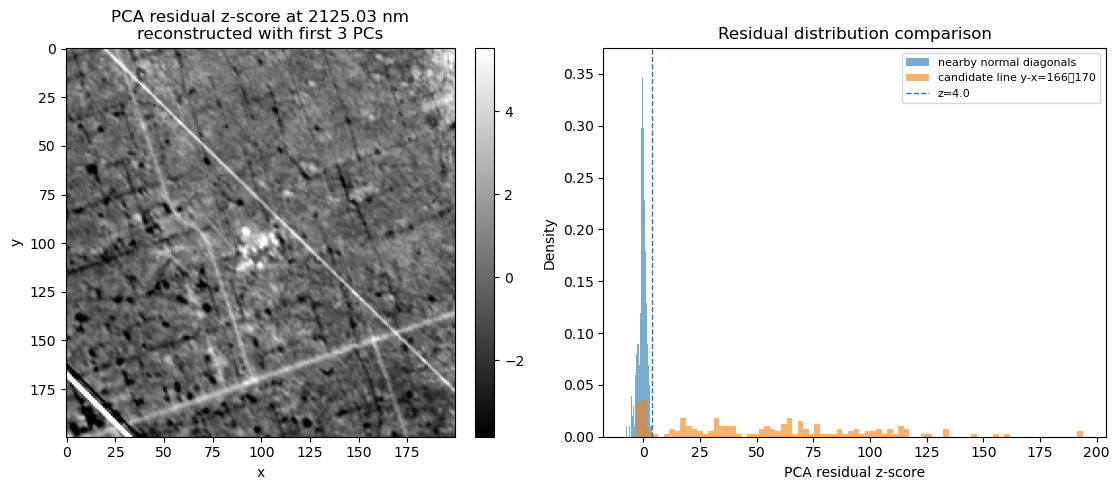

Saved: D:\research\code\diagonal_spike_tolerant_output\pca_residual_2125.03nm.png


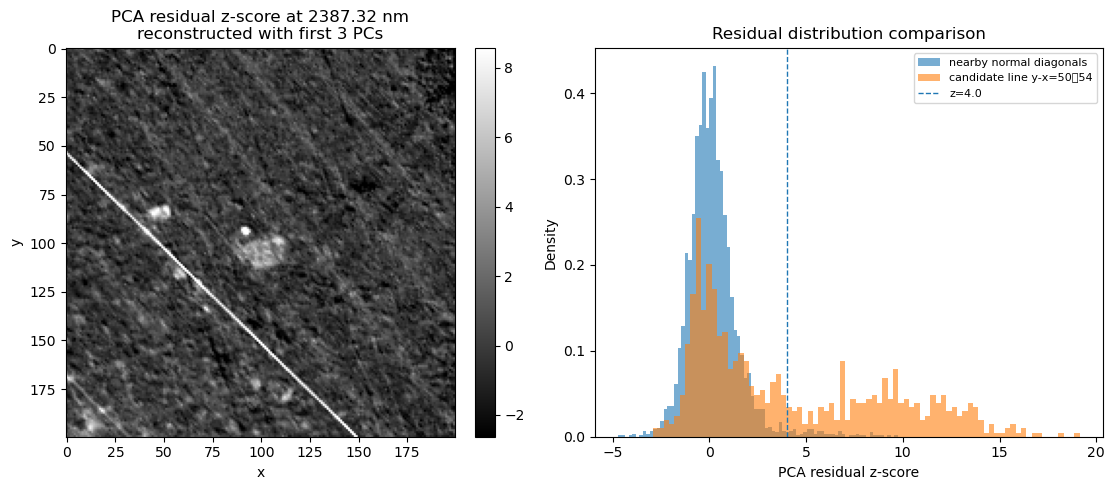

Saved: D:\research\code\diagonal_spike_tolerant_output\pca_residual_2387.32nm.png


,target_wavelength_nm,actual_band_nm,candidate_d_range,n_line_pixels,line_mean_residual_z,line_median_residual_z,line_fraction_z_gt_4.0,normal_mean_residual_z,normal_fraction_z_gt_4.0,line_max_residual_z
0,2125.03,2125.03,166 to 170,160,53.643494,52.449210,0.812500,-0.493935,0.000000,193.839693
1,2387.32,2387.32,50 to 54,740,4.201369,2.269818,0.404054,0.177732,0.019656,19.146829


In [9]:
# ============================================================
# 指定波長の PCA residual z-score 画像を表示
# ============================================================

summary_rows = []

for target_wl in TARGET_WLS:
    k = nearest_band_index(target_wl, wl_pca)
    actual_wl = wl_pca[k]

    residual_img = residual[:, k].reshape(height, width)
    residual_z = robust_zscore_1d(residual_img.ravel()).reshape(height, width)

    d_min, d_max = TARGET_DIAG_RANGES[target_wl]

    line_mask = (D >= d_min) & (D <= d_max)

    # 比較用：候補線から少し離れた対角線
    normal_mask = (
        ((D >= d_min - 15) & (D <= d_min - 5))
        | ((D >= d_max + 5) & (D <= d_max + 15))
    )

    normal_mask &= ~line_mask

    summary_rows.append({
        "target_wavelength_nm": target_wl,
        "actual_band_nm": actual_wl,
        "candidate_d_range": f"{d_min} to {d_max}",
        "n_line_pixels": int(line_mask.sum()),
        "line_mean_residual_z": float(np.nanmean(residual_z[line_mask])),
        "line_median_residual_z": float(np.nanmedian(residual_z[line_mask])),
        f"line_fraction_z_gt_{Z_THRESHOLD}": float(np.nanmean(residual_z[line_mask] > Z_THRESHOLD)),
        "normal_mean_residual_z": float(np.nanmean(residual_z[normal_mask])),
        f"normal_fraction_z_gt_{Z_THRESHOLD}": float(np.nanmean(residual_z[normal_mask] > Z_THRESHOLD)),
        "line_max_residual_z": float(np.nanmax(residual_z[line_mask])),
    })

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 残差z-score画像
    vmin, vmax = np.nanpercentile(residual_z, [1, 99.5])

    im = axes[0].imshow(
        residual_z,
        origin="upper",
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
    )

    axes[0].set_title(
        f"PCA residual z-score at {actual_wl:.2f} nm\n"
        f"reconstructed with first {N_PC_RECON} PCs"
    )
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_aspect("equal")
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    # ヒストグラム比較
    axes[1].hist(
        residual_z[normal_mask].ravel(),
        bins=80,
        alpha=0.6,
        density=True,
        label="nearby normal diagonals",
    )

    axes[1].hist(
        residual_z[line_mask].ravel(),
        bins=80,
        alpha=0.6,
        density=True,
        label=f"candidate line y-x={d_min}〜{d_max}",
    )

    axes[1].axvline(Z_THRESHOLD, linestyle="--", linewidth=1, label=f"z={Z_THRESHOLD}")
    axes[1].set_xlabel("PCA residual z-score")
    axes[1].set_ylabel("Density")
    axes[1].set_title("Residual distribution comparison")
    axes[1].legend(fontsize=8)

    fig.tight_layout()

    save_path = OUT_DIR / f"pca_residual_{actual_wl:.2f}nm.png"
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved: {save_path}")

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

summary_df.to_csv(OUT_DIR / "pca_residual_summary.csv", index=False)

In [10]:
# ============================================================
# 各波長について、PCA residual が大きい対角線をランキング
# ============================================================

DIAG_HALF_WIDTH = 2
MIN_PIXELS = 80

for target_wl in TARGET_WLS:
    k = nearest_band_index(target_wl, wl_pca)
    actual_wl = wl_pca[k]

    residual_img = residual[:, k].reshape(height, width)
    residual_z = robust_zscore_1d(residual_img.ravel()).reshape(height, width)

    rows = []

    for d_center in range(-(width - 1), height):
        mask = np.abs(D - d_center) <= DIAG_HALF_WIDTH

        if mask.sum() < MIN_PIXELS:
            continue

        vals = residual_z[mask]

        rows.append({
            "d_center_y_minus_x": int(d_center),
            "n_pixels": int(mask.sum()),
            "mean_residual_z": float(np.nanmean(vals)),
            "median_residual_z": float(np.nanmedian(vals)),
            f"fraction_residual_z_gt_{Z_THRESHOLD}": float(np.nanmean(vals > Z_THRESHOLD)),
            "max_residual_z": float(np.nanmax(vals)),
        })

    diag_rank = pd.DataFrame(rows).sort_values(
        [f"fraction_residual_z_gt_{Z_THRESHOLD}", "mean_residual_z"],
        ascending=False,
    ).reset_index(drop=True)

    print(f"\n===== PCA residual diagonal ranking at {actual_wl:.2f} nm =====")
    display(diag_rank.head(20))

    save_path = OUT_DIR / f"pca_residual_diag_rank_{actual_wl:.2f}nm.csv"
    diag_rank.to_csv(save_path, index=False)
    print(f"Saved: {save_path}")


===== PCA residual diagonal ranking at 2125.03 nm =====


,d_center_y_minus_x,n_pixels,mean_residual_z,median_residual_z,fraction_residual_z_gt_4.0,max_residual_z
0,168,160,53.643494,52.449210,0.812500,193.839693
1,167,165,51.535765,50.162178,0.787879,193.839693
2,169,155,49.670277,54.454410,0.619355,193.839693
3,166,170,40.136816,21.181103,0.582353,193.839693
4,170,150,35.732477,1.784491,0.420000,193.839693
5,165,175,15.375393,-0.950388,0.382857,109.374825
6,171,145,10.873968,0.143032,0.213793,114.747146
7,164,180,-0.058752,-3.048391,0.188889,40.949533
8,-21,895,1.626612,1.111551,0.165363,8.608968
9,-22,890,1.654538,1.109919,0.162921,8.608968


Saved: D:\research\code\diagonal_spike_tolerant_output\pca_residual_diag_rank_2125.03nm.csv

===== PCA residual diagonal ranking at 2387.32 nm =====


,d_center_y_minus_x,n_pixels,mean_residual_z,median_residual_z,fraction_residual_z_gt_4.0,max_residual_z
0,52,740,4.201369,2.269818,0.404054,19.146829
1,53,735,3.975383,1.851457,0.379592,19.146829
2,51,745,3.737457,1.418811,0.351678,19.146829
3,54,730,3.022847,0.854289,0.294521,19.146829
4,180,100,2.212529,1.646614,0.250000,7.667512
5,179,105,2.027526,1.417466,0.247619,6.945709
6,50,750,2.641589,0.747315,0.245333,18.117655
7,181,95,2.277131,1.590885,0.242105,7.918583
8,178,110,1.954018,1.567570,0.227273,6.251096
9,182,90,2.175430,1.487582,0.211111,7.918583


Saved: D:\research\code\diagonal_spike_tolerant_output\pca_residual_diag_rank_2387.32nm.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import math
from pathlib import Path
from sklearn.decomposition import PCA
from IPython.display import display
CSV_PATH = Path(r"D:\research\code\all_roi_spectra200x200.csv")
OUT_DIR = Path(r"D:\research\code\diagonal_spike_tolerant_output")
OUT_DIR = Path(OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)
# settings
WL_MIN = 2100
WL_MAX = 2400

# number of PCs to show
N_SHOW_PC = 8

# number of PCs to use for PCA reconstruction
N_PC_TOTAL = 12

# number of PCs to use for PCA residual calculation
# too small -> local anomalies remain in residual, too large -> residual mostly noise
N_PC_RECON = 3

# wavelengths to visualize
TARGET_WLS = [2125.03, 2174.99, 2387.32]


def robust_zscore_1d(v):
    v = np.asarray(v, dtype=float)
    med = np.nanmedian(v)
    mad = np.nanmedian(np.abs(v - med))
    scale = mad / 0.6745

    if not np.isfinite(scale) or scale < 1e-12:
        scale = np.nanstd(v)

    if not np.isfinite(scale) or scale < 1e-12:
        return np.zeros_like(v)

    return (v - med) / scale


def nearest_band_index(target_wl, wavelengths):
    wavelengths = np.asarray(wavelengths, dtype=float)
    return int(np.argmin(np.abs(wavelengths - target_wl)))


# if "cube" not in globals():

if "cube" not in globals():
    wave_cols = [c for c in df.columns if c.startswith("wave_")]

    wavelengths = np.array([
        float(re.search(r"wave_([0-9.]+)nm", c).group(1))
        for c in wave_cols
    ])

    height = int(df["y"].max()) + 1
    width = int(df["x"].max()) + 1

    cube = np.full((height, width, len(wave_cols)), np.nan, dtype=float)
    cube[
        df["y"].to_numpy(dtype=int),
        df["x"].to_numpy(dtype=int),
        :
    ] = df[wave_cols].to_numpy(dtype=float)

else:
    height, width, n_bands = cube.shape

# make sure wavelengths is numpy array

wl_mask = (wavelengths >= WL_MIN) & (wavelengths <= WL_MAX)
wl_pca = wavelengths[wl_mask]

X_raw = cube[:, :, wl_mask].reshape(-1, wl_mask.sum())

valid_pixel_mask = np.all(np.isfinite(X_raw), axis=1)
X_valid = X_raw[valid_pixel_mask]

# normolize per band
mu = np.nanmean(X_valid, axis=0)
sd = np.nanstd(X_valid, axis=0, ddof=1)
sd[sd < 1e-12] = 1.0

X_std = (X_valid - mu) / sd

print("PCA input shape:", X_std.shape)
print("Wavelength range:", wl_pca[0], "to", wl_pca[-1], "nm")
print("Valid pixels:", valid_pixel_mask.sum())

PCA input shape: (40000, 25)
Wavelength range: 2100.05 to 2399.82 nm
Valid pixels: 40000


In [ ]:
# calculate PCA scores

pca = PCA(n_components=N_PC_TOTAL, random_state=0)
scores = pca.fit_transform(X_std)

explained = pd.DataFrame({
    "PC": np.arange(1, N_PC_TOTAL + 1),
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative": np.cumsum(pca.explained_variance_ratio_)
})

display(explained)

explained.to_csv(OUT_DIR / "pca_explained_variance.csv", index=False)

,PC,explained_variance_ratio,cumulative
0,1,0.984944,0.984944
1,2,0.007170,0.992114
2,3,0.004605,0.996719
3,4,0.001345,0.998064
4,5,0.000585,0.998649
5,6,0.000451,0.999100
6,7,0.000342,0.999442
7,8,0.000102,0.999544
8,9,0.000079,0.999623
9,10,0.000071,0.999695


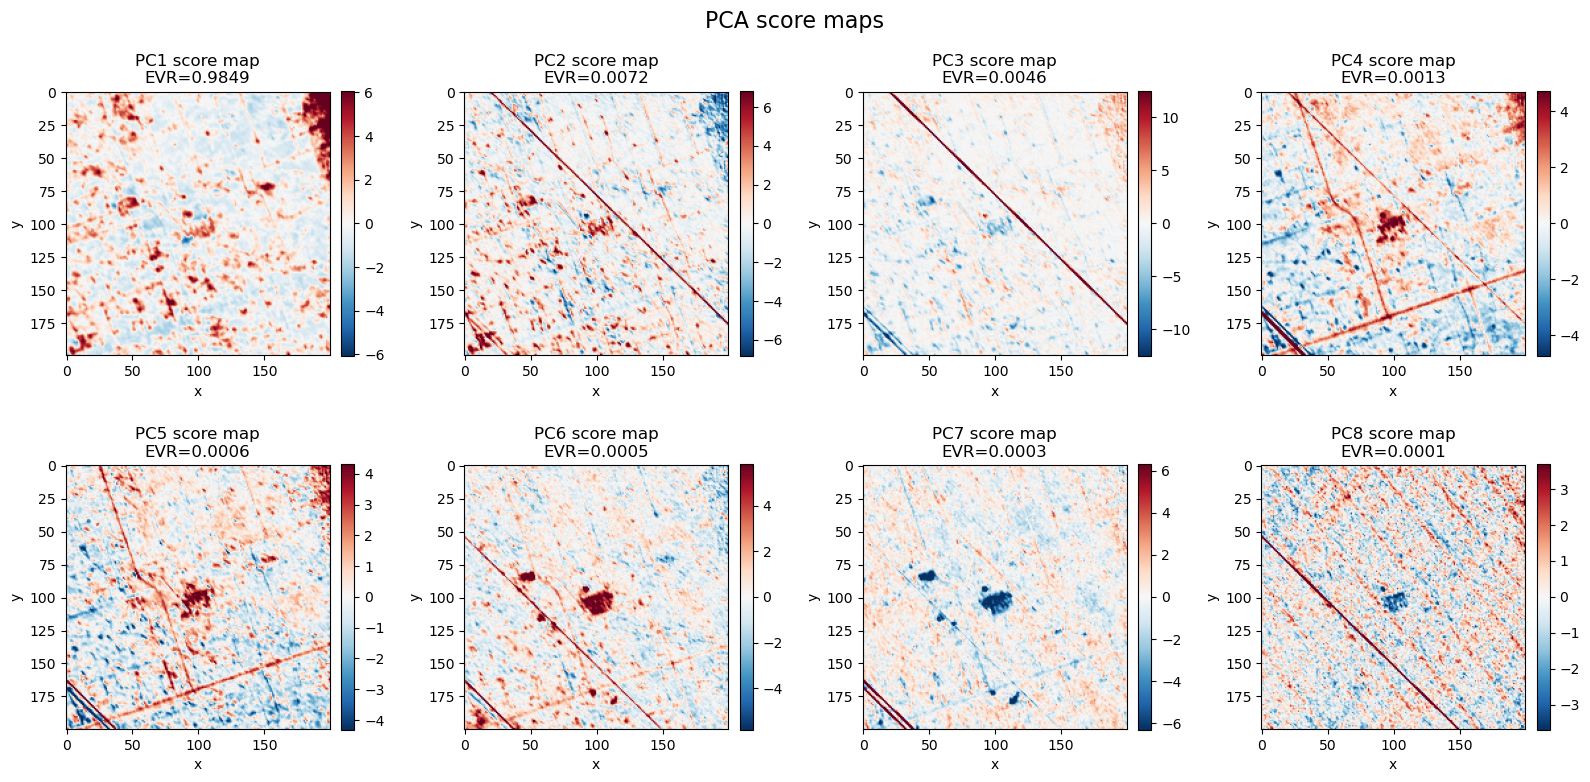

Saved: D:\research\code\diagonal_spike_tolerant_output\pca_score_maps_PC1_PC8.png


In [13]:
# show PCA score maps

n_show = min(N_SHOW_PC, scores.shape[1])

ncols = 4
nrows = math.ceil(n_show / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.array(axes).reshape(-1)

for i in range(n_show):
    score_full = np.full(height * width, np.nan, dtype=float)
    score_full[valid_pixel_mask] = scores[:, i]

    score_img = score_full.reshape(height, width)
    score_z = robust_zscore_1d(score_img.ravel()).reshape(height, width)

    vals = score_z[np.isfinite(score_z)]
    vmax = np.nanpercentile(np.abs(vals), 99)
    vmin = -vmax

    ax = axes[i]
    im = ax.imshow(
        score_z,
        origin="upper",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(
        f"PC{i+1} score map\n"
        f"EVR={pca.explained_variance_ratio_[i]:.4f}"
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for j in range(n_show, len(axes)):
    axes[j].axis("off")

fig.suptitle("PCA score maps", fontsize=16)
fig.tight_layout()

save_path = OUT_DIR / "pca_score_maps_PC1_PC8.png"
fig.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {save_path}")